In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import json
import joblib
import warnings
warnings.filterwarnings('ignore')

# Model libraries
from sklearn.model_selection import (
    StratifiedKFold,
    RepeatedStratifiedKFold,
    cross_validate,
    learning_curve,
    validation_curve
)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, average_precision_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    precision_recall_curve
)
from sklearn.base import clone

# Ensemble models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier,
    RandomForestClassifier, 
    ExtraTreesClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Hyperparameter tuning
import optuna
from optuna.samplers import TPESampler

# Interpretability
import shap

# =============================================================================
# CONFIGURATION
# =============================================================================
RANDOM_STATE = 42
TARGET_COL = 'TenYearCHD'

# =============================================================================
# 1. DATA LOADING AND PREPARATION
# =============================================================================

def load_presplit_data(train_filepath,
                       test_filepath,
                       target_col_name='TenYearCHD'):
    """
    Load pre-split train and test datasets
    """
    print("="*80)
    print("STEP 1: LOADING PRE-SPLIT DATA")
    print("="*80)
    
    # Load training data
    print(f"\n✓ Loading training data from: {train_filepath}")
    train_df = pd.read_csv(train_filepath)
    print(f"  Shape: {train_df.shape}")
    
    # Load test data
    print(f"\n✓ Loading test data from: {test_filepath}")
    test_df = pd.read_csv(test_filepath)
    print(f"  Shape: {test_df.shape}")
    
    # Find target column
    if target_col_name not in train_df.columns:
        possible_targets = ['TenYearCHD', 'target', 'ten_year_chd']
        target_found = False
        for col in possible_targets:
            if col in train_df.columns:
                target_col_name = col
                target_found = True
                print(f"\n✓ Target column found: {target_col_name}")
                break
        
        if not target_found:
            raise ValueError(f"Target column '{target_col_name}' not found. Available columns: {train_df.columns.tolist()}")
    else:
        print(f"\n✓ Target column: {target_col_name}")
    
    # Separate features and target
    X_train = train_df.drop(columns=[target_col_name])
    y_train = train_df[target_col_name]
    
    X_test = test_df.drop(columns=[target_col_name])
    y_test = test_df[target_col_name]
    
    print(f"\n✓ Data split information:")
    print(f"  Training set: {X_train.shape}")
    print(f"  Test set: {X_test.shape}")
    
    # Verify feature consistency
    if list(X_train.columns) != list(X_test.columns):
        raise ValueError("Training and test sets have different features!")
    
    print(f"\n✓ Feature consistency verified")
    
    # Class distribution
    train_dist = y_train.value_counts().sort_index()
    print(f"\n✓ Training Set Class Distribution:")
    print(f"  Class 0 (No CHD): {train_dist[0]} ({train_dist[0]/len(y_train)*100:.2f}%)")
    print(f"  Class 1 (CHD): {train_dist[1]} ({train_dist[1]/len(y_train)*100:.2f}%)")
    print(f"  Imbalance Ratio: {train_dist[0]/train_dist[1]:.2f}:1")
    
    test_dist = y_test.value_counts().sort_index()
    print(f"\n✓ Test Set Class Distribution:")
    print(f"  Class 0 (No CHD): {test_dist[0]} ({test_dist[0]/len(y_test)*100:.2f}%)")
    print(f"  Class 1 (CHD): {test_dist[1]} ({test_dist[1]/len(y_test)*100:.2f}%)")
    print(f"  Imbalance Ratio: {test_dist[0]/test_dist[1]:.2f}:1")
    
    # Handle missing values
    train_missing = X_train.isnull().sum()
    test_missing = X_test.isnull().sum()
    
    if train_missing.any() or test_missing.any():
        print(f"\n⚠ Warning: Missing values detected")
        for col in X_train.columns:
            if X_train[col].dtype in ['float64', 'int64']:
                median_val = X_train[col].median()
                X_train[col].fillna(median_val, inplace=True)
                X_test[col].fillna(median_val, inplace=True)
            else:
                mode_val = X_train[col].mode()[0] if len(X_train[col].mode()) > 0 else X_train[col].iloc[0]
                X_train[col].fillna(mode_val, inplace=True)
                X_test[col].fillna(mode_val, inplace=True)
    
    # Handle categorical variables
    categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
    
    if categorical_cols:
        print(f"\n✓ Encoding categorical variables: {categorical_cols}")
        label_encoders = {}
        for col in categorical_cols:
            le = LabelEncoder()
            X_train[col] = le.fit_transform(X_train[col].astype(str))
            X_test[col] = le.transform(X_test[col].astype(str))
            label_encoders[col] = le
    else:
        label_encoders = None
        print(f"\n✓ No categorical variables found (all numeric)")
    
    feature_names = X_train.columns.tolist()
    print(f"\n✓ Features ({len(feature_names)}):")
    for i, feat in enumerate(feature_names, 1):
        print(f"  {i:2d}. {feat}")
    
    return X_train, X_test, y_train, y_test, feature_names, label_encoders


# =============================================================================
# 2. HYPERPARAMETER TUNING WITH OPTUNA
# =============================================================================

XGB_PARAM_SPACE = {
    'n_estimators': lambda t: t.suggest_int('n_estimators', 200, 800),
    'max_depth': lambda t: t.suggest_int('max_depth', 3, 8),
    'learning_rate': lambda t: t.suggest_float('learning_rate', 0.01, 0.2),
    'subsample': lambda t: t.suggest_float('subsample', 0.6, 1),
    'colsample_bytree': lambda t: t.suggest_float('colsample_bytree', 0.6, 1.0),
    'min_child_weight': lambda t: t.suggest_int('min_child_weight', 1, 10),
    'gamma': lambda t: t.suggest_float('gamma', 0, 5),
    'reg_alpha': lambda t: t.suggest_float('reg_alpha', 0, 5),
    'reg_lambda': lambda t: t.suggest_float('reg_lambda', 0.5, 5)
}

LGBM_PARAM_SPACE = {
    'n_estimators': lambda t: t.suggest_int('n_estimators', 200, 800),
    'num_leaves': lambda t: t.suggest_int('num_leaves', 20, 80),
    'learning_rate': lambda t: t.suggest_float('learning_rate', 0.01, 0.2),
    'subsample': lambda t: t.suggest_float('subsample', 0.6, 1.0),
    'colsample_bytree': lambda t: t.suggest_float('colsample_bytree', 0.3, 1.0),
    'min_data_in_leaf': lambda t: t.suggest_int('min_data_in_leaf', 20, 100),
    'lambda_l1': lambda t: t.suggest_float('lambda_l1', 0, 5),
    'lambda_l2': lambda t: t.suggest_float('lambda_l2', 0, 5)
}

def tune_boosting_model(model_class, param_space, X_train, y_train, n_trials=50, model_name="Model"):
    """
    Optimize XGBoost or LightGBM hyperparameters using Optuna.
    """
    print("\n" + "="*80)
    print(f"HYPERPARAMETER TUNING - {model_name}")
    print("="*80)
    
    # Calculate scale_pos_weight
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    print(f"\n✓ Calculated scale_pos_weight: {scale_pos_weight:.2f}")
    
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)
    
    def objective(trial):
        params = {k: v(trial) for k, v in param_space.items()}
        
        scores = []
        for train_idx, val_idx in cv.split(X_train, y_train):
            X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            
            model = model_class(**params)
            model.fit(X_tr, y_tr)
            
            probs = model.predict_proba(X_val)[:, 1]
            preds = (probs >= 0.5).astype(int)
            
            roc = roc_auc_score(y_val, probs)
            recall = recall_score(y_val, preds)
            pr_auc = average_precision_score(y_val, probs)

            scores.append(0.6*roc + 0.2*recall + 0.2*pr_auc)
        
        return np.mean(scores)
    
    print(f"\n✓ Starting Optuna optimization ({n_trials} trials)...")
    print("  Objective: 0.6*ROC-AUC + 0.2*Recall + 0.2*PR-AUC")
    
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=n_trials)
    
    print(f"\n✓ Optimization completed!")
    print(f"  Best ROC-AUC: {study.best_value:.4f}")
    print(f"  Best parameters:")
    for key, value in study.best_params.items():
        print(f"    {key}: {value}")
    
    best_params = study.best_params.copy()

    best_params.update({
        'eval_metric': 'auc',
        'random_state': RANDOM_STATE
    })

    if model_class == XGBClassifier:
        best_params.update({'scale_pos_weight': scale_pos_weight, 'use_label_encoder': False})
    elif model_class == LGBMClassifier:
        best_params.update({'class_weight':'balanced', 'verbose': -1})
        
    return best_params


def tune_adaboost(X_train, y_train, n_trials=40):
    """
    Optimize AdaBoost hyperparameters using Optuna
    Uses sample_weight to handle imbalance
    """
    print("\n" + "="*80)
    print("HYPERPARAMETER TUNING - AdaBoost")
    print("="*80)

    # Calculate sample weights for imbalance
    class_counts = y_train.value_counts()
    class_weight = len(y_train) / (2 * class_counts)
    sample_weights = y_train.map(class_weight)
    
    print(f"\n✓ Using sample_weight to handle imbalance")
    print(f"  Class 0 weight: {class_weight[0]:.3f}")
    print(f"  Class 1 weight: {class_weight[1]:.3f}")
    
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 400),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0),
            'algorithm': 'SAMME',  # Better for probability estimates
            'random_state': RANDOM_STATE,
        }
        
        model = AdaBoostClassifier(**params)
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
        
        scores = []
        for train_idx, val_idx in cv.split(X_train, y_train):
            X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            sw_tr = sample_weights.iloc[train_idx]
            
            # Fit with sample weights
            model.fit(X_tr, y_tr, sample_weight=sw_tr)
            y_pred_proba = model.predict_proba(X_val)[:, 1]
            score = roc_auc_score(y_val, y_pred_proba)
            scores.append(score)
        
        return np.mean(scores)
    
    print(f"\n✓ Starting Optuna optimization ({n_trials} trials)...")
    print("  Objective: 0.6*ROC-AUC + 0.2*Recall + 0.2*PR-AUC")
    
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    
    print(f"\n✓ Optimization completed!")
    print(f"  Best ROC-AUC: {study.best_value:.4f}")
    print(f"  Best parameters:")
    for key, value in study.best_params.items():
        print(f"    {key}: {value}")
    
    best_params = study.best_params.copy()
    best_params['random_state'] = RANDOM_STATE
    
    return best_params


# =============================================================================
# 3. MODEL TRAINING AND EVALUATION
# =============================================================================

def train_base_models(X_train, y_train, X_test, y_test, 
                     best_xgb_params, best_lgbm_params, best_ada_params):
    """
    Train base ensemble models with optimized hyperparameters
    """
    print("\n" + "="*80)
    print("TRAINING BASE ENSEMBLE MODELS")
    print("="*80)
    
    models = {
        'XGBoost': XGBClassifier(**best_xgb_params),
        'LightGBM': LGBMClassifier(**best_lgbm_params),
        'AdaBoost': AdaBoostClassifier(**best_ada_params)
    }
    
    results = {}
    trained_models = {}
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scoring = {
        'accuracy': 'accuracy',
        'precision': 'precision',
        'recall': 'recall',
        'f1': 'f1',
        'roc_auc': 'roc_auc'
    }
    
    for name, model in models.items():
        print(f"\n{'='*80}")
        print(f"Training: {name}")
        print(f"{'='*80}")
        
        # Cross-validation
        print(f"  Running 5-fold cross-validation...")

        if name == 'AdaBoost':
            # For AdaBoost, we custom CV with sample_weight
            cv_scores = {'test_roc_auc': [], 'test_recall': [], 'test_precision': [], 
                        'test_f1': [], 'test_accuracy': []}
            
            cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

                # Calculate sample weights for imbalance
            class_counts = y_train.value_counts()
            class_weight = len(y_train) / (2 * class_counts)
            sample_weights = y_train.map(class_weight)
            for train_idx, val_idx in cv.split(X_train, y_train):
                X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
                y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
                sw_tr = sample_weights.iloc[train_idx]
                
                model.fit(X_tr, y_tr, sample_weight=sw_tr)
                y_pred = model.predict(X_val)
                y_proba = model.predict_proba(X_val)[:, 1]
                
                cv_scores['test_roc_auc'].append(roc_auc_score(y_val, y_proba))
                cv_scores['test_recall'].append(recall_score(y_val, y_pred))
                cv_scores['test_precision'].append(precision_score(y_val, y_pred, zero_division=0))
                cv_scores['test_f1'].append(f1_score(y_val, y_pred))
                cv_scores['test_accuracy'].append(accuracy_score(y_val, y_pred))
            
            cv_results = {k: np.array(v) for k, v in cv_scores.items()}
            
            # Train final model with sample weights
            model.fit(X_train, y_train, sample_weight=sample_weights)
        else:
            cv_results = cross_validate(
                model, X_train, y_train,
                cv=cv, scoring=scoring, n_jobs=-1,
                return_train_score=True
            )
            model.fit(X_train, y_train)
        
        # Predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        y_test_proba = model.predict_proba(X_test)[:, 1]
        
        # Calculate metrics
        train_metrics = {
            'accuracy': accuracy_score(y_train, y_train_pred),
            'precision': precision_score(y_train, y_train_pred, zero_division=0),
            'recall': recall_score(y_train, y_train_pred),
            'f1': f1_score(y_train, y_train_pred),
            'roc_auc': roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
        }
        
        test_metrics = {
            'accuracy': accuracy_score(y_test, y_test_pred),
            'precision': precision_score(y_test, y_test_pred, zero_division=0),
            'recall': recall_score(y_test, y_test_pred),
            'f1': f1_score(y_test, y_test_pred),
            'roc_auc': roc_auc_score(y_test, y_test_proba)
        }
        
        cv_metrics = {
            'cv_accuracy_mean': cv_results['test_accuracy'].mean(),
            'cv_accuracy_std': cv_results['test_accuracy'].std(),
            'cv_precision_mean': cv_results['test_precision'].mean(),
            'cv_precision_std': cv_results['test_precision'].std(),
            'cv_recall_mean': cv_results['test_recall'].mean(),
            'cv_recall_std': cv_results['test_recall'].std(),
            'cv_f1_mean': cv_results['test_f1'].mean(),
            'cv_f1_std': cv_results['test_f1'].std(),
            'cv_roc_auc_mean': cv_results['test_roc_auc'].mean(),
            'cv_roc_auc_std': cv_results['test_roc_auc'].std(),
        }
        
        # Store results
        results[name] = {
            'train_metrics': train_metrics,
            'metrics': test_metrics,
            'cv_metrics': cv_metrics,
            'confusion_matrix': confusion_matrix(y_test, y_test_pred),
            'y_pred': y_test_pred,
            'y_proba': y_test_proba
        }
        
        trained_models[name] = model
        
        # Print results
        print(f"\n  Cross-Validation Results (mean ± std):")
        print(f"    Accuracy:  {cv_metrics['cv_accuracy_mean']:.4f} ± {cv_metrics['cv_accuracy_std']:.4f}")
        print(f"    Precision: {cv_metrics['cv_precision_mean']:.4f} ± {cv_metrics['cv_precision_std']:.4f}")
        print(f"    Recall:    {cv_metrics['cv_recall_mean']:.4f} ± {cv_metrics['cv_recall_std']:.4f}")
        print(f"    F1-Score:  {cv_metrics['cv_f1_mean']:.4f} ± {cv_metrics['cv_f1_std']:.4f}")
        print(f"    ROC-AUC:   {cv_metrics['cv_roc_auc_mean']:.4f} ± {cv_metrics['cv_roc_auc_std']:.4f}")
        
        print(f"\n  Test Set Performance:")
        print(f"    Accuracy:  {test_metrics['accuracy']:.4f}")
        print(f"    Precision: {test_metrics['precision']:.4f}")
        print(f"    Recall:    {test_metrics['recall']:.4f}")
        print(f"    F1-Score:  {test_metrics['f1']:.4f}")
        print(f"    ROC-AUC:   {test_metrics['roc_auc']:.4f}")
    
    return results, trained_models

def create_base_models(pos_weight):
    """
    Create base learners with reasonably good defaults.
    Returns a dict of instantiated models.
    """
    base_models = dict()
    
    base_models['xgb'] = XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.08,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=10,
        reg_lambda=1.0,
        reg_alpha=0.1,
        scale_pos_weight=pos_weight,
        objective='binary:logistic',
        eval_metric='auc',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    base_models['lgbm'] = LGBMClassifier(
        n_estimators=400,
        learning_rate=0.08,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=40,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        reg_alpha=0.1,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    base_models['rf'] = RandomForestClassifier(
        n_estimators=400,
        max_depth=8,
        min_samples_leaf=10,
        min_samples_split=20,
        class_weight='balanced_subsample',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    base_models['et'] = ExtraTreesClassifier(
        n_estimators=400,
        max_depth=8,
        min_samples_leaf=10,
        min_samples_split=20,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    base_models['svm'] = SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        probability=True,
        class_weight='balanced',
        random_state=RANDOM_STATE
    )
    
    return base_models

def create_stacking_ensemble(base_model_keys, X_train, y_train):
    """
    General function to create a stacking ensemble from a selection of base models.
    """
    base_models = create_base_models(pos_weight=(len(y_train) - sum(y_train)) / sum(y_train))
    
    estimators = [(name, base_models[name]) for name in base_model_keys]

    meta_learner = LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        penalty='l2',
        solver='lbfgs',
        random_state=RANDOM_STATE
    )

    stacking_model = StackingClassifier(
        estimators=estimators,
        final_estimator=meta_learner,
        stack_method='predict_proba',
        cv=5,
        n_jobs=-1,
        passthrough=False
    )

    print("\n✓ Training stacking ensemble...")
    print(f"  Base estimators: {[name for name, _ in estimators]}")
    print(f"  Meta-learner: Logistic Regression")
    
    stacking_model.fit(X_train, y_train)

    print("✓ Stacking ensemble trained successfully")
    
    return stacking_model

# -----------------------------------------
# Wrapper functions for the two recommended ensembles
# -----------------------------------------
def create_stacking_xgb_lgbm_rf_et(X_train, y_train):
    return create_stacking_ensemble(['xgb', 'lgbm', 'rf', 'et'], X_train, y_train)

def create_stacking_xgb_lgbm_rf_svm(X_train, y_train):
    return create_stacking_ensemble(['xgb', 'lgbm', 'rf', 'svm'], X_train, y_train)

def evaluate_model(model, X_test, y_test, threshold):
    """
    Comprehensive model evaluation
    """
    probs = model.predict_proba(X_test)[:, 1]
    preds = (probs >= threshold).astype(int)
    
    metrics = {
        'accuracy': accuracy_score(y_test, preds),
        'precision': precision_score(y_test, preds, zero_division=0),
        'recall': recall_score(y_test, preds),
        'f1': f1_score(y_test, preds),
        'pr_auc': average_precision_score(y_test, probs),
        'roc_auc': roc_auc_score(y_test, probs),
        "threshold": threshold
    }
    
    cm = confusion_matrix(y_test, preds)
    
    return {
        'metrics': metrics,
        'confusion_matrix': cm
    }
    
# =============================================================================
# 4. THRESHOLD OPTIMIZATION
# =============================================================================

def optimize_threshold_for_recall(model, X, y):
    """
    Optimize classification threshold using F1-score,
    returning the threshold and the recall achieved at that threshold.
    """
    probs = model.predict_proba(X)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y, probs)

    f1 = (
        2 * precision * recall /
        (precision + recall + 1e-8)
    )
    
    idx = np.argmax(f1)
    optimal_threshold = thresholds[idx] if idx < len(thresholds) else 0.5
    optimal_recall = recall[idx]
    
    return optimal_threshold, optimal_recall


# =============================================================================
# 5. VISUALIZATION
# =============================================================================

def plot_roc_curves(results_dict, y_test, scaling_type='unscaled'):
    """
    Plot ROC curves for all models
    """
    filename = f'roc_curve_{scaling_type}.png'
    plt.figure(figsize=(10, 8))

    for name, results in results_dict.items():
        if 'y_proba' not in results:
            raise KeyError(f"Missing y_proba for model '{name}'")
            
        fpr, tpr, _ = roc_curve(y_test, results['y_proba'])
        auc = results['metrics']['roc_auc']
        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})", linewidth=2)

    plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5000)')
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'ROC Curves - Model Comparison ({scaling_type})', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✓ ROC curves saved: {filename}")


def plot_confusion_matrices(results_dict, scaling_type='unscaled'):
    """
    Plot confusion matrices for all models
    """
    filename = f'confusion_matrices_{scaling_type}.png'
    n_models = len(results_dict)
    fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 4))
    axes = np.atleast_1d(axes)

    for ax, (name, results) in zip(axes, results_dict.items()):
        cm = confusion_matrix(results['y_true'], results['y_pred'])
        sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues')
        ax.set_title(f"{name}", fontweight='bold')
        ax.set_xlabel('Predicted label')
        ax.set_ylabel('True label')

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✓ Confusion matrices saved: {filename}")


# =============================================================================
# 6. FEATURE IMPORTANCE AND INTERPRETABILITY
# =============================================================================

def analyze_feature_importance(model, feature_names, model_name, scaling_type='unscaled'):
    """
    Analyze and plot feature importance
    """
    print(f"\n{'='*80}")
    print(f"Feature Importance Analysis - {model_name}")
    print(f"{'='*80}")

    filename = f'feature_importance_{model_name.lower().replace(" ", "_")}_{scaling_type}.png'

    # -------------------------------
    # CASE 1: Single tree-based model
    # -------------------------------
    if hasattr(model, 'feature_importances_'):
        # Build and sort DataFrame
        importance_df = (
            pd.DataFrame({
                'feature': feature_names,
                'importance': model.feature_importances_
            })
            .sort_values('importance', ascending=False)
            .reset_index(drop=True)
        )

    # -------------------------------
    # CASE 2: Stacked ensemble
    # -------------------------------
    elif hasattr(model, "final_estimator_"):
        print("✓ Detected stacked ensemble model")

        # Attempt to get base model names
        if hasattr(model, "named_estimators_"):
            base_names = list(model.named_estimators_.keys())
        elif hasattr(model, "base_estimators_"):  # custom wrapper
            base_names = [f"model_{i}" for i in range(len(model.base_estimators_))]
        elif hasattr(model, "estimators_"):      # fallback
            base_names = [f"model_{i}" for i in range(len(model.estimators_))]
        else:
            base_names = [f"model_{i}" for i in range(10)]  # fallback

        meta_model = model.final_estimator_

        if not hasattr(meta_model, "coef_"):
            print("⚠️ Meta-model does not expose coefficients")
            return pd.DataFrame()

        # Use absolute value of coefficients as importance
        importances = np.abs(meta_model.coef_).ravel()
        meta_feature_names = [f"{name}_pred" for name in base_names]

        importance_df = (
            pd.DataFrame({
                'feature': meta_feature_names,
                'importance': importances
            })
            .sort_values('importance', ascending=False)
            .reset_index(drop=True)
        )
    
    # -------------------------------
    # CASE 3: Unsupported model
    # -------------------------------
    else:
        print(f"⚠️ {model_name} has no supported feature importance method")
        return pd.DataFrame()
        
    # Print top 10
    print(f"\nTop 10 Most Important Features:")
    for _, row in importance_df.head(10).iterrows():
        print(f"  {row['feature']:25s}: {row['importance']:.4f}")

    # Plot top N
    top_n = min(15, len(importance_df))
    y_pos = np.arange(top_n)
    
    plt.figure(figsize=(10, 8))
    plt.barh(y_pos, importance_df['importance'].head(top_n))
    plt.yticks(y_pos, importance_df['feature'].head(top_n))
    plt.gca().invert_yaxis()
    plt.title(f'Feature Importance - {model_name} ({scaling_type})', fontsize=14, fontweight='bold')
    plt.xlabel('Importance', fontsize=12)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()

    print(f"✓ Feature importance plot saved: {filename}")

    return importance_df


def shap_analysis(model, X_test, feature_names, model_name, scaling_type='unscaled', max_display=15):
    """
    SHAP analysis for model interpretability
    """
    print(f"\n{'='*80}")
    print(f"SHAP Analysis - {model_name}")
    print(f"{'='*80}")
    
    try:
        filename = f'shap_summary_{model_name.lower()}_{scaling_type}.png'
        
        print("\n✓ Creating SHAP explainer...")
        explainer = shap.TreeExplainer(model)
        
        sample_size = min(500, len(X_test))
        X_sample = X_test.sample(n=sample_size, random_state=RANDOM_STATE)
        
        print(f"✓ Calculating SHAP values for {sample_size} samples...")
        shap_values = explainer.shap_values(X_sample)
        
        if isinstance(shap_values, list):
            shap_values = shap_values[1]
        
        # Summary plot
        plt.figure(figsize=(10, 8))
        shap.summary_plot(shap_values, X_sample, feature_names=feature_names,
                         max_display=max_display, show=False)
        plt.tight_layout()
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.close()
        print(f"✓ SHAP summary plot saved: {filename}")
        
        shap_importance = np.abs(shap_values).mean(axis=0)
        shap_df = pd.DataFrame({
            'feature': feature_names,
            'shap_importance': shap_importance
        }).sort_values('shap_importance', ascending=False)
        
        print(f"\nTop 10 Features by SHAP Importance:")
        for idx, row in shap_df.head(10).iterrows():
            print(f"  {row['feature']:25s}: {row['shap_importance']:.4f}")
        
        return shap_df
        
    except Exception as e:
        print(f"✗ SHAP analysis failed: {str(e)}")
        return None


# =============================================================================
# 7. LEARNING AND VALIDATION CURVES
# =============================================================================

def plot_learning_curves(model, X_train, y_train, model_name, scaling_type='unscaled'):
    """
    Plot learning curves
    """
    print(f"\n{'='*80}")
    print(f"Learning Curves - {model_name.lower()}_{scaling_type}")
    print(f"{'='*80}")

    filename = f'learning_curves_{model_name.lower()}_{scaling_type}.png'
    
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train, y_train,
        train_sizes=np.linspace(0.1, 1.0, 5),
        cv=5,
        scoring='roc_auc',
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
    
    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training score')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, 
                     alpha=0.1, color='blue')
    plt.plot(train_sizes, val_mean, 'o-', color='red', label='Cross-validation score')
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, 
                     alpha=0.1, color='red')
    
    plt.xlabel('Training Set Size', fontsize=12)
    plt.ylabel('ROC-AUC Score', fontsize=12)
    plt.title(f'Learning Curves -  {model_name} ({scaling_type})', fontsize=14, fontweight='bold')
    plt.legend(loc='best', fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"✓ Learning curves saved: {filename}")
    plt.close()
    
    return {
        'train_sizes': train_sizes.tolist(),
        'train_auc': train_mean.tolist(),
        'val_auc': val_mean.tolist()
    }


def plot_validation_curve(model, X_train, y_train, model_name, scaling_type='unscaled'):
    """
    Plot validation curve for n_estimators
    """
    print(f"\n{'='*80}")
    print(f"Validation Curve - {model_name.lower()}_{scaling_type}")
    print(f"{'='*80}")

    filename = f'validation_curve_{model_name.lower()}_{scaling_type}.png'

    if not hasattr(model, 'n_estimators'):
        print(f"  Model does not have n_estimators parameter")
        return None
    
    param_range = [50, 100, 200, 400]
    
    train_scores, val_scores = validation_curve(
        model, X_train, y_train,
        param_name='n_estimators',
        param_range=param_range,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1
    )
    
    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(param_range, train_mean, 'o-', color='blue', label='Training score')
    plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, 
                     alpha=0.1, color='blue')
    plt.plot(param_range, val_mean, 'o-', color='red', label='Cross-validation score')
    plt.fill_between(param_range, val_mean - val_std, val_mean + val_std, 
                     alpha=0.1, color='red')
    
    plt.xlabel('n_estimators', fontsize=12)
    plt.ylabel('ROC-AUC Score', fontsize=12)
    plt.title(f'Validation Curve - {model_name.lower()}_{scaling_type} - n_estimators', 
              fontsize=14, fontweight='bold')
    plt.legend(loc='best', fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"✓ Validation curve saved: {filename}")
    plt.close()
    
    return {
        'param_name': 'n_estimators',
        'param_range': param_range,
        'train_auc': train_mean.tolist(),
        'val_auc': val_mean.tolist()
    }


# =============================================================================
# 8. MODEL SELECTION
# =============================================================================

def select_best_model(results_dict, models_dict, X_test, y_test):
    """
    Select best model based on weighted score:
    0.6 * ROC-AUC + 0.2 * Recall + 0.2 * PR-AUC
    Thresholds from results_dict are used if available; otherwise 0.5 is default.
    """
    print("\n" + "="*80)
    print("MODEL SELECTION (Weighted: 0.6*ROC-AUC + 0.2*Recall + 0.2*PR-AUC)")
    print("="*80)
    
    weighted_scores = {}
    
    for name, model in models_dict.items():
        # Use threshold from results_dict if present, else default 0.5
        threshold = results_dict[name].get("threshold", 0.5)
        if threshold == 0.5:
            print(f"⚠ Warning: threshold not found for {name}, using 0.5 by default")

        # Evaluate using custom threshold
        metrics = evaluate_model(model, X_test, y_test, threshold)['metrics']
        
        roc_auc = metrics["roc_auc"]
        recall = metrics["recall"]
        pr_auc = metrics["pr_auc"]
        
        weighted_score = 0.6 * roc_auc + 0.2 * recall + 0.2 * pr_auc
        weighted_scores[name] = weighted_score
        
        print(f"\n{name}:")
        print(f"  ROC-AUC: {roc_auc:.4f}")
        print(f"  Recall:  {recall:.4f}")
        print(f"  PR-AUC:  {pr_auc:.4f}")
        print(f"  Weighted Score: {weighted_score:.4f}")
    
    best_model_name = max(weighted_scores, key=weighted_scores.get)
    best_model = models_dict[best_model_name]
    
    print("\n" + "="*80)
    print(f"🏆 BEST MODEL: {best_model_name}")
    print(f"   Weighted Score: {weighted_scores[best_model_name]:.4f}")
    print("="*80)
    
    return best_model_name, best_model, weighted_scores


# =============================================================================
# 9. SAVE MODEL AND METADATA
# =============================================================================

def save_final_model(model, model_name, feature_names, metrics, 
                     hyperparameters, final_scores, optimal_threshold,
                     optimal_recall, learning_curve_data, validation_curve_data,
                     label_encoders=None, scaling_type='unscaled', save_dir='models'):
    """
    Save the final selected model with complete metadata
    """
    print("\n" + "="*80)
    print("SAVING FINAL MODEL")
    print("="*80)
    
    os.makedirs(save_dir, exist_ok=True)
    
    model_filename = f'best_model_{scaling_type}.pkl'
    metadata_filename = f'model_metadata_{scaling_type}.json'
    encoders_filename = f'label_encoders_{scaling_type}.pkl'
    
    # Save model
    model_path = os.path.join(save_dir, model_filename)
    metadata_path = os.path.join(save_dir, metadata_filename)
    encoders_path = os.path.join(save_dir, encoders_filename)
    
    joblib.dump(model, model_path)
    print(f"\n✓ Model saved: {model_path}")

    if model_name.lower().startswith('stack'):
        learning_curve_data = None
        validation_curve_data = None
    
    # Save metadata
    metadata = {
        'model_name': model_name,
        'model_type': type(model).__name__,
        'scaling_type': scaling_type,
        'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'feature_names': feature_names,
        'n_features': len(feature_names),
        'test_metrics': metrics,
        'tuned_hyperparameters': hyperparameters,
        'final_weighted_scores': final_scores,
        'optimal_threshold': float(optimal_threshold),
        'optimal_recall': float(optimal_recall),
        'learning_curve': learning_curve_data,
        'validation_curve': validation_curve_data,
        'imbalance_handling': 'scale_pos_weight / class_weight',
        'hyperparameter_tuning': 'Optuna (boosting) + threshold optimization',
        'label_encoders': {k: v.classes_.tolist() for k, v in label_encoders.items()} 
                          if label_encoders else None,
    }
    
    with open(metadata_path, 'w') as f:
        json.dump(metadata, f, indent=4)
    print(f"✓ Metadata saved: {metadata_path}")
    
    if label_encoders:
        joblib.dump(label_encoders, encoders_path)
        print(f"✓ Label encoders saved: {encoders_path}")
    
    print(f"\n✓ All artifacts saved to: {save_dir}/")
    
    return model_path, metadata_path


def create_model_comparison_csv(results_dict, scaling_type='unscaled'):
    """
    Create CSV file comparing all models
    """
    print("\n" + "="*80)
    print("CREATING MODEL COMPARISON TABLE")
    print("="*80)

    filename = f'model_comparison_{scaling_type}.csv'
    
    all_metrics = []
    
    for name, results in results_dict.items():
        metrics = results['metrics']
        metrics['model'] = name
        all_metrics.append(metrics)
    
    df = pd.DataFrame(all_metrics)
    df = df.sort_values('ROC-AUC', ascending=False)
    df.to_csv(filename, index=False)
    
    print(f"\n✓ Model comparison saved: {filename}")
    print("\nModel Comparison Table:")
    print(df.to_string(index=False))
    
    return df


# =============================================================================
# 10. MAIN EXECUTION PIPELINE
# =============================================================================

def main(train_filepath=None,
         test_filepath=None,
         target_col_name='TenYearCHD', 
         scaling_type='unscaled'):
    """
    Main execution pipeline for Collaborator 5
    """
    print("\n" + "="*80)
    print("CORONARY HEART DISEASE PREDICTION PROJECT")
    print("Advanced Models & Model Selection - Collaborator 5")
    print("="*80)
    print(f"Start Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("="*80)
    
    # =========================================================================
    # STEP 1: Load data
    # =========================================================================
    assert train_filepath and test_filepath, "Please provide train and test file paths"
    X_train, X_test, y_train, y_test, feature_names, label_encoders = load_presplit_data(
        train_filepath=train_filepath,
        test_filepath=test_filepath,
        target_col_name=target_col_name
    )
    
    # =========================================================================
    # STEP 2: Hyperparameter tuning with Optuna
    # =========================================================================
    best_xgb_params = tune_boosting_model(XGBClassifier, XGB_PARAM_SPACE, X_train, y_train, model_name="XGBoost")
    best_lgbm_params = tune_boosting_model(LGBMClassifier, LGBM_PARAM_SPACE, X_train, y_train, model_name="LightGBM")
    best_ada_params = tune_adaboost(X_train, y_train, n_trials=40)
    
    all_hyperparameters = {
        'xgboost': best_xgb_params,
        'lightgbm': best_lgbm_params,
        'adaboost': best_ada_params
    }
    
    # =========================================================================
    # STEP 3: Train base models
    # =========================================================================
    base_results, base_models = train_base_models(
        X_train, y_train, X_test, y_test,
        best_xgb_params, best_lgbm_params, best_ada_params
    )
    
    # =========================================================================
    # STEP 4: Threshold optimization for base models
    # =========================================================================
    for name, model in base_models.items():
        threshold, opt_recall = optimize_threshold_for_recall(model, X_train, y_train)
        base_results[name]['threshold'] = threshold
        base_results[name]['optimal_recall'] = opt_recall
        print(f"\n{name}: Optimal Threshold = {threshold:.3f}, Recall = {opt_recall:.3f}")
      
    # =========================================================================
    # STEP 5: Create stacking ensembles
    # =========================================================================
    
    stacking_ensembles = {
        "Stacking_ET": create_stacking_xgb_lgbm_rf_et(X_train, y_train),
        "Stacking_SVM": create_stacking_xgb_lgbm_rf_svm(X_train, y_train)
    }
    
    for name, model in stacking_ensembles.items():
        # Optimize threshold using F1-score (or recall-focused metric)
        threshold, optimal_recall = optimize_threshold_for_recall(model, X_train, y_train)
        print(f"\n✓ Optimized threshold for {name}: {threshold:.3f} "
              f"with recall: {optimal_recall:.3f}")
        
        y_test_proba = model.predict_proba(X_test)[:, 1]
    
        # Evaluate stacking model on test set using optimized threshold
        results = evaluate_model(model, X_test, y_test, threshold)
        results['threshold'] = threshold
        results['optimal_recall'] = optimal_recall
        results['y_proba'] = y_test_proba
    
        # Add repeated stratified CV metrics
        cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)
        roc_scores, recall_scores = [], []
    
        for train_idx, val_idx in cv.split(X_train, y_train):
            X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
            model.fit(X_tr, y_tr)
            y_val_probs = model.predict_proba(X_val)[:, 1]
            y_val_pred = (y_val_probs >= threshold).astype(int)
    
            roc_scores.append(roc_auc_score(y_val, y_val_probs))
            recall_scores.append(recall_score(y_val, y_val_pred))
    
        results['cv_roc_auc_mean'] = np.mean(roc_scores)
        results['cv_roc_auc_std'] = np.std(roc_scores)
        results['cv_recall_mean'] = np.mean(recall_scores)
        results['cv_recall_std'] = np.std(recall_scores)
    
        # Store results in base_results
        base_results[name] = results
    
        print(f"\n✓ {name} model created and metrics added to the results table.")

    # =========================================================================
    # STEP 6: Visualizations
    # =========================================================================
    print("\n" + "="*80)
    print("GENERATING VISUALIZATIONS")
    print("="*80)
    
    plot_roc_curves(base_results, y_test, scaling_type=scaling_type)
    plot_confusion_matrices(base_results, scaling_type=scaling_type)
    
    # =========================================================================
    # STEP 7: Feature importance
    # =========================================================================
    print("\n" + "="*80)
    print("FEATURE IMPORTANCE & INTERPRETABILITY")
    print("="*80)
   
    feature_importance_dict = {}
    
    # Analyze all models
    for model_name in base_models:
        importance_df = analyze_feature_importance(
            base_models[model_name], feature_names, model_name, scaling_type=scaling_type
        )
        if importance_df is not None:
            feature_importance_dict[model_name] = importance_df
    
    # =========================================================================
    # STEP 8: Learning and validation curves (before model selection)
    # =========================================================================
    print("\n" + "="*80)
    print("LEARNING AND VALIDATION CURVES - TOP MODELS")
    print("="*80)
    
    # Generate for top 2 models
    learning_curves_dict = {}
    validation_curves_dict = {}
    
    for model_name in ['Stacking_ET', 'Stacking_SVM']:
        learning_curves_dict[model_name] = plot_learning_curves(
            base_models[model_name], X_train, y_train, model_name
        )
        
        validation_curves_dict[model_name] = plot_validation_curve(
            base_models[model_name], X_train, y_train, model_name
        )

    # =========================================================================
    # STEP 9: Create comparison table
    # =========================================================================    
    comparison_df = create_model_comparison_csv(base_results, scaling_type=scaling_type)

    # =========================================================================
    # STEP 10: Model selection
    # =========================================================================    
        # Include all base models plus both stacking ensembles
    all_models = {}
    all_models.update(base_models)
    all_models.update(stacking_ensembles)
    # Select the best model based on the evaluation metrics stored in base_results
    best_model_name, best_model, final_scores = select_best_model(base_results, all_models, X_test, y_test)
    
    print(f"\n🏆 Best model selected: {best_model_name}")
        
    # =========================================================================
    # STEP 11: SHAP ANALYSIS - Best model only
    # =========================================================================
    ("\n" + "="*80)
    print(f"SHAP ANALYSIS - {best_model_name} (BEST MODEL)")
    print("="*80)
    
    best_model_shap_importance = shap_analysis(
        best_model, X_test, feature_names, best_model_name, scaling_type=scaling_type
    )

    # =========================================================================
    # STEP 12: Save final model
    # =========================================================================
    best_metrics = base_results[best_model_name]['metrics']
    optimal_threshold = base_results[best_model_name].get('threshold', 0.5)
    optimal_recall = base_results[best_model_name].get('optimal_recall', None)
    
    model_path, metadata_path = save_final_model(
        best_model, best_model_name, feature_names,
        best_metrics, all_hyperparameters, final_scores,
        optimal_threshold, optimal_recall,
        learning_curves_dict[best_model_name] if best_model_name in learning_curves_dict else None,
        validation_curves_dict[best_model_name] if best_model_name in validation_curves_dict else None,
        label_encoders, scaling_type=scaling_type
    )
    
    # =========================================================================
    # FINAL SUMMARY
    # =========================================================================
    print("\n" + "="*80)
    print("DETAILED RESULTS")
    print("="*80)
    
    for model_name, results in base_results.items():
        print(f"\n{'='*80}")
        print(f"MODEL: {model_name}")
        print(f"{'='*80}")
        
        metrics = results['metrics']
        print(f"\nTest Set Performance:")
        print(f"  Accuracy:  {metrics['accuracy']:.4f}")
        print(f"  Precision: {metrics['precision']:.4f}")
        print(f"  Recall:    {metrics['recall']:.4f}")
        print(f"  F1-Score:  {metrics['f1']:.4f}")
        print(f"  ROC-AUC:   {metrics['roc_auc']:.4f}")
    
        if 'cv_roc_auc_mean' in results:
            print(f"\nCross-Validation:")
            print(f"  ROC-AUC: {results.get('cv_roc_auc_mean', 'N/A'):.4f}")
            print(f"  Recall:  {results.get('cv_recall_mean', 'N/A'):.4f}")
        elif 'cv_metrics' in results:
            cv = results['cv_metrics']
            print(f"\nCross-Validation:")
            print(f"  ROC-AUC: {cv['cv_roc_auc_mean']:.4f} ± {cv['cv_roc_auc_std']:.4f}")
            print(f"  Recall:  {cv['cv_recall_mean']:.4f} ± {cv['cv_recall_std']:.4f}")
        
        cm = results['confusion_matrix']
        print(f"\nConfusion Matrix:")
        print(f"  TN: {cm[0][0]:4d}  FP: {cm[0][1]:4d}")
        print(f"  FN: {cm[1][0]:4d}  TP: {cm[1][1]:4d}")
    
    print("\n" + "="*80)
    print("FINAL SUMMARY")
    print("="*80)
    
    print(f"\n🏆 Best Model: {best_model_name}")
    print(f"\nKey Performance Metrics:")
    print(f"  • ROC-AUC:   {best_metrics['roc_auc']:.4f}")
    print(f"  • Recall:    {best_metrics['recall']:.4f}")
    print(f"  • Precision: {best_metrics['precision']:.4f}")
    print(f"  • F1-Score:  {best_metrics['f1']:.4f}")
    print(f"  • Accuracy:  {best_metrics['accuracy']:.4f}")
    print(f"\n📝 Imbalance Handling: scale_pos_weight")
    print(f"📝 Hyperparameter Tuning: Optuna (50 trials)")
    print(f"📝 Optimal Threshold: {optimal_threshold:.4f}")
    
    print(f"\n📁 Outputs Generated:")
    print(f"  • Model file: {model_path}")
    print(f"  • Metadata: {metadata_path}")
    print(f"  • Model comparison: model_comparison.csv")
    print(f"  • ROC curves: roc_curves_comparison.png")
    print(f"  • Confusion matrices: confusion_matrices.png")
    print(f"  • Feature importance plots")
    print(f"  • SHAP analysis plots")
    print(f"  • Learning curves")
    print(f"  • Validation curves")
    
    print("\n" + "="*80)
    print(f"End Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("COLLABORATOR 5 TASKS COMPLETED SUCCESSFULLY!")
    print("="*80)


    return {
        'best_model': best_model,
        'best_model_name': best_model_name,
        'all_models': all_models,
        'all_results': base_results,
        'feature_importance': xgb_importance,
        'shap_importance': best_model_shap_importance,
        'comparison_df': comparison_df,
        'hyperparameters': all_hyperparameters,
        'final_scores': final_scores
    }

[I 2026-01-13 13:12:39,109] A new study created in memory with name: no-name-52fb5488-15f5-455a-b747-20432a2fc206



 RUNNING PIPELINE FOR DATASET VERSION: UNSCALED

CORONARY HEART DISEASE PREDICTION PROJECT
Advanced Models & Model Selection - Collaborator 5
Start Time: 2026-01-13 13:12:39
STEP 1: LOADING PRE-SPLIT DATA

✓ Loading training data from: ../data/processed\train_unscaled.csv
  Shape: (3390, 9)

✓ Loading test data from: ../data/processed\test_unscaled.csv
  Shape: (848, 9)

✓ Target column: TenYearCHD

✓ Data split information:
  Training set: (3390, 8)
  Test set: (848, 8)

✓ Feature consistency verified

✓ Training Set Class Distribution:
  Class 0 (No CHD): 2875 (84.81%)
  Class 1 (CHD): 515 (15.19%)
  Imbalance Ratio: 5.58:1

✓ Test Set Class Distribution:
  Class 0 (No CHD): 719 (84.79%)
  Class 1 (CHD): 129 (15.21%)
  Imbalance Ratio: 5.57:1

✓ No categorical variables found (all numeric)

✓ Features (8):
   1. bmi
   2. hypertension
   3. pulse_pressure
   4. cigarettes_per_day
   5. total_cholesterol
   6. glucose
   7. heart_rate
   8. age_group_code

HYPERPARAMETER TUNING - XGB

[I 2026-01-13 13:12:40,589] Trial 0 finished with value: 0.48389007867522754 and parameters: {'n_estimators': 425, 'max_depth': 8, 'learning_rate': 0.14907884894416698, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 2, 'gamma': 0.2904180608409973, 'reg_alpha': 4.330880728874676, 'reg_lambda': 3.20501755284444}. Best is trial 0 with value: 0.48389007867522754.
[I 2026-01-13 13:12:41,827] Trial 1 finished with value: 0.49469054703824894 and parameters: {'n_estimators': 625, 'max_depth': 3, 'learning_rate': 0.19428287191077892, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'min_child_weight': 2, 'gamma': 0.9170225492671691, 'reg_alpha': 1.5212112147976886, 'reg_lambda': 2.86140394234507}. Best is trial 1 with value: 0.49469054703824894.
[I 2026-01-13 13:12:42,774] Trial 2 finished with value: 0.49972839856696666 and parameters: {'n_estimators': 459, 'max_depth': 4, 'learning_rate': 0.1262520499972521, 'subsample': 0.


✓ Optimization completed!
  Best ROC-AUC: 0.5034
  Best parameters:
    n_estimators: 342
    max_depth: 6
    learning_rate: 0.02748901717175932
    subsample: 0.6251483563604947
    colsample_bytree: 0.7701255525617435
    min_child_weight: 6
    gamma: 4.397578207071795
    reg_alpha: 0.2631402151220623
    reg_lambda: 1.1272267197301336

HYPERPARAMETER TUNING - LightGBM

✓ Calculated scale_pos_weight: 5.58

✓ Starting Optuna optimization (50 trials)...
  Objective: 0.6*ROC-AUC + 0.2*Recall + 0.2*PR-AUC


[I 2026-01-13 13:13:34,989] Trial 0 finished with value: 0.4619753451665209 and parameters: {'n_estimators': 425, 'num_leaves': 77, 'learning_rate': 0.14907884894416698, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.40921304830970556, 'min_data_in_leaf': 32, 'lambda_l1': 0.2904180608409973, 'lambda_l2': 4.330880728874676}. Best is trial 0 with value: 0.4619753451665209.
[I 2026-01-13 13:13:39,091] Trial 1 finished with value: 0.478127042671654 and parameters: {'n_estimators': 561, 'num_leaves': 63, 'learning_rate': 0.013911053916202464, 'subsample': 0.9879639408647978, 'colsample_bytree': 0.8827098485602951, 'min_data_in_leaf': 37, 'lambda_l1': 0.9091248360355031, 'lambda_l2': 0.9170225492671691}. Best is trial 1 with value: 0.478127042671654.
[I 2026-01-13 13:13:41,196] Trial 2 finished with value: 0.4729747929311613 and parameters: {'n_estimators': 382, 'num_leaves': 52, 'learning_rate': 0.092069553542002, 'subsample': 0.7164916560792167, 'colsample_bytree': 0.72829702630566


✓ Optimization completed!
  Best ROC-AUC: 0.4972
  Best parameters:
    n_estimators: 795
    num_leaves: 47
    learning_rate: 0.06072830385962023
    subsample: 0.6026269635481769
    colsample_bytree: 0.34377904437860135
    min_data_in_leaf: 100
    lambda_l1: 4.985823074966434
    lambda_l2: 3.3840902904780745

HYPERPARAMETER TUNING - AdaBoost

✓ Using sample_weight to handle imbalance
  Class 0 weight: 0.590
  Class 1 weight: 3.291

✓ Starting Optuna optimization (40 trials)...
  Objective: 0.6*ROC-AUC + 0.2*Recall + 0.2*PR-AUC


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-01-13 13:14:42,887] Trial 0 finished with value: 0.7106171380329254 and parameters: {'n_estimators': 181, 'learning_rate': 0.951207163345817}. Best is trial 0 with value: 0.7106171380329254.
[I 2026-01-13 13:14:44,843] Trial 1 finished with value: 0.7139535669058674 and parameters: {'n_estimators': 306, 'learning_rate': 0.6026718993550663}. Best is trial 1 with value: 0.7139535669058674.
[I 2026-01-13 13:14:45,523] Trial 2 finished with value: 0.7127412410299704 and parameters: {'n_estimators': 104, 'learning_rate': 0.16443457513284063}. Best is trial 1 with value: 0.7139535669058674.
[I 2026-01-13 13:14:45,973] Trial 3 finished with value: 0.7081992401857323 and parameters: {'n_estimators': 70, 'learning_rate': 0.8675143843171859}. Best is trial 1 with value: 0.7139535669058674.
[I 2026-01-13 13:14:47,625] Trial 4 finished with value: 0.7106542845082313 and parameters: {'n_estimators': 260, 'learning_rate': 0.710991852018085}. Best is trial 1 with value: 0.7139535669058674.
[I

KeyError: 'y_true'

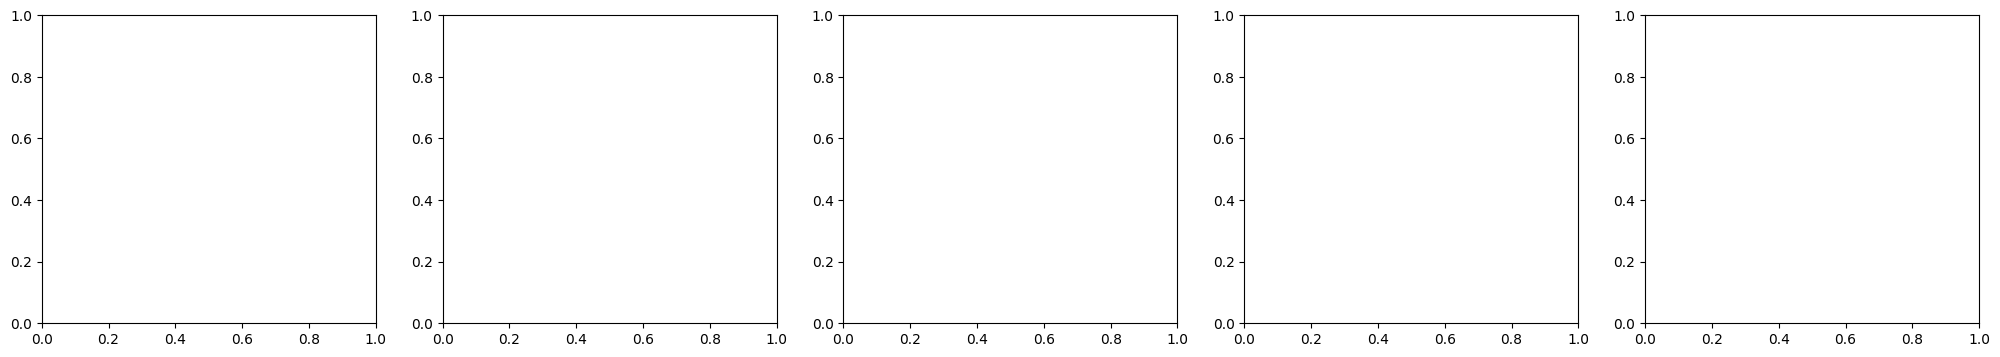

In [12]:
DATASET_VERSIONS = ["unscaled", "standard_scaled", "robust_scaled"]

DATA_DIR = "../data/processed"

all_results = {}

for scaling_type in DATASET_VERSIONS:
    print("\n" + "=" * 100)
    print(f" RUNNING PIPELINE FOR DATASET VERSION: {scaling_type.upper()}")
    print("=" * 100)

    train_fp = os.path.join(DATA_DIR, f"train_{scaling_type}.csv")
    test_fp = os.path.join(DATA_DIR, f"test_{scaling_type}.csv")

    results = main(
        train_filepath=train_fp,
        test_filepath=test_fp,
        target_col_name="TenYearCHD",
        scaling_type=scaling_type
    )

    all_results[scaling_type] = results


In [ ]:
import os
import sys

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
    
from src.models.traditional_ml import (
    load_dataset
)

DATA_DIR = '../data/processed'
FIG_DIR = '../figures/02_ML_Models'
MODELS_DIR = '../models'
RANDOM_STATE = 42

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

comparison_traditional = 'model_comparison.csv'
traditional_comparison_df = load_dataset(os.path.join(DATA_DIR, comparison_traditional))

display(traditional_comparison_df.sort_values("test_roc_auc", ascending=False).head())